# Lesson 2.4 — Pressure-Velocity Coupling

## The Chicken-and-Egg Problem

Look at the N-S momentum equation:

$$\frac{\partial \mathbf{u}}{\partial t} = -\frac{\nabla p}{\rho} - (\mathbf{u}\cdot\nabla)\mathbf{u} + \nu\nabla^2\mathbf{u}$$

To advance $\mathbf{u}$ in time, we need $p$. But there is no *equation of state* for $p$ in
incompressible flow — pressure adjusts instantaneously to enforce $\nabla\cdot\mathbf{u}=0$.
This is the **pressure-velocity coupling problem**.

The solution: derive a **Poisson equation** for pressure by combining momentum and continuity.

---

## Deriving the Pressure Poisson Equation

Take the divergence of the momentum equation:

$$\nabla \cdot \frac{\partial \mathbf{u}}{\partial t} = -\frac{1}{\rho}\nabla^2 p - \nabla \cdot [(\mathbf{u}\cdot\nabla)\mathbf{u}] + \nu \nabla^2(\nabla\cdot\mathbf{u})$$

Since $\nabla\cdot\mathbf{u}=0$ (and must remain so at all times), $\nabla\cdot(\partial\mathbf{u}/\partial t) = 0$
and the viscous term vanishes:

$$\boxed{\nabla^2 p = -\rho \nabla \cdot [(\mathbf{u}\cdot\nabla)\mathbf{u}]}$$

In 2D, the right-hand side expands to:

$$\nabla^2 p = -\rho \left[ \left(\frac{\partial u}{\partial x}\right)^2 + 2\frac{\partial u}{\partial y}\frac{\partial v}{\partial x} + \left(\frac{\partial v}{\partial y}\right)^2 \right]$$

This is the **pressure Poisson equation (PPE)**. Given $\mathbf{u}$, solve this for $p$.
Then use $p$ to correct $\mathbf{u}$.

---

## The Checkerboard Problem

If you naively store $u$, $v$, and $p$ at the same grid points (co-located), the central-difference
pressure gradient at point $i$ uses $p_{i+1}$ and $p_{i-1}$ — **skipping the point at $i$ itself**.
This means a checkerboard pressure field (alternating high/low) has zero pressure gradient!

The spurious solution: $p = A(-1)^{i+j}$ is indistinguishable from $p = 0$ in the momentum equation.

---

## The Staggered Grid — The Fix

Store $u$ at x-face centres, $v$ at y-face centres, $p$ at cell centres.

```
    v
    ↑
 ───┼───
 p  →  u
 ───┼───
```

The pressure gradient at a $u$-face: uses $p$ at the two adjacent cell centres (no skipping).
The divergence at a $p$-cell: uses $u$ at the two adjacent u-faces (no skipping).

This eliminates the checkerboard mode completely.


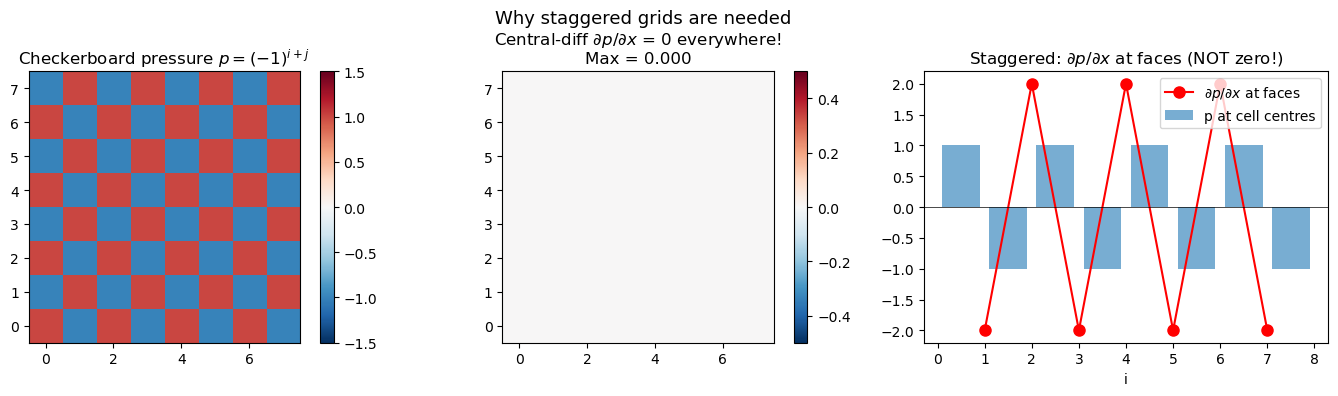

Co-located: checkerboard pressure → zero gradient (spurious mode).
Staggered:  pressure gradient at faces → correctly detects oscillation.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Demonstrate the checkerboard pressure problem on a co-located grid
N = 8
i, j = np.meshgrid(range(N), range(N))

# Checkerboard pressure
p_checker = (-1.0) ** (i + j)

# Central difference pressure gradient (dp/dx at each point)
dpdx = np.zeros((N, N))
dpdx[:, 1:-1] = (p_checker[:, 2:] - p_checker[:, :-2]) / 2.0

# Uniform pressure for comparison
p_uniform = np.ones((N, N))
dpdx_uniform = np.zeros((N, N))
dpdx_uniform[:, 1:-1] = (p_uniform[:, 2:] - p_uniform[:, :-2]) / 2.0

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Checkerboard pattern
im0 = axes[0].imshow(p_checker, cmap='RdBu_r', vmin=-1.5, vmax=1.5, origin='lower')
plt.colorbar(im0, ax=axes[0])
axes[0].set_title('Checkerboard pressure $p = (-1)^{i+j}$')

# Its gradient (should be large, but computed as zero!)
im1 = axes[1].imshow(dpdx, cmap='RdBu_r', vmin=-0.5, vmax=0.5, origin='lower')
plt.colorbar(im1, ax=axes[1])
axes[1].set_title(f'Central-diff $\\partial p/\\partial x$ = 0 everywhere!\nMax = {np.max(np.abs(dpdx)):.3f}')

# Staggered grid: p at cell centres, dp/dx at faces
# Simulate staggered: compute dp/dx between cell centres
x_cell = np.arange(N) + 0.5
p_1d = p_checker[N//2, :]  # take middle row
dpdx_staggered = p_1d[1:] - p_1d[:-1]  # difference between adjacent cells
x_face = np.arange(N-1) + 1.0

axes[2].bar(x_cell, p_1d, width=0.8, alpha=0.6, label='p at cell centres')
axes[2].plot(x_face, dpdx_staggered, 'ro-', markersize=8, label='$\\partial p/\\partial x$ at faces')
axes[2].axhline(0, color='k', linewidth=0.5)
axes[2].set_title('Staggered: $\\partial p/\\partial x$ at faces (NOT zero!)')
axes[2].legend()
axes[2].set_xlabel('i')

plt.suptitle('Why staggered grids are needed', fontsize=13)
plt.tight_layout()
plt.show()

print("Co-located: checkerboard pressure → zero gradient (spurious mode).")
print("Staggered:  pressure gradient at faces → correctly detects oscillation.")

Converged in 1643 iterations
Max error: 7.0905e-01


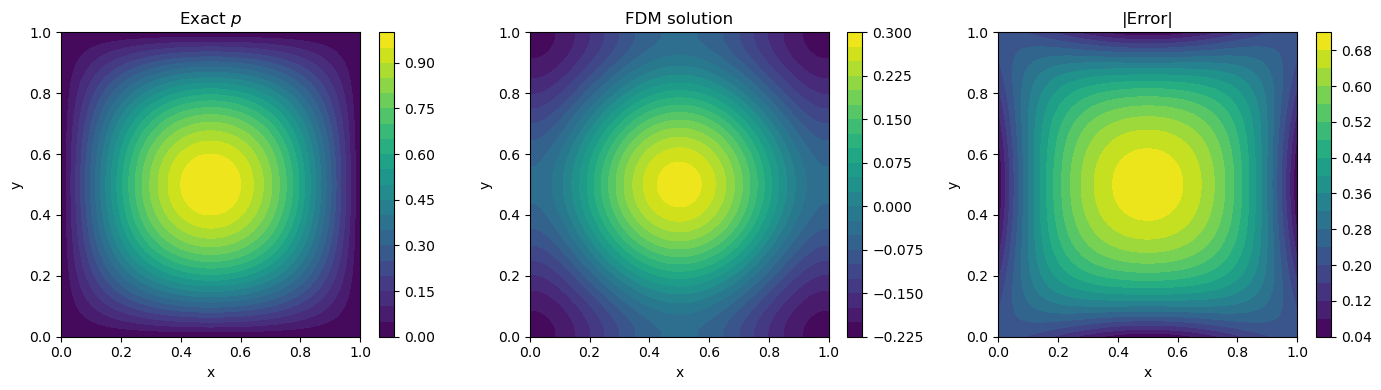

In [2]:
# Solve the pressure Poisson equation: Laplacian(p) = RHS
# For a known RHS, verify against exact solution
# RHS = -2*pi^2 * sin(pi*x)*sin(pi*y) → p = sin(pi*x)*sin(pi*y)

def solve_poisson(rhs, dx, dy, tol=1e-6, max_iter=10000):
    """Solve Laplacian(p) = rhs using Gauss-Seidel iteration."""
    ny, nx = rhs.shape
    p = np.zeros_like(rhs)
    
    for it in range(max_iter):
        p_old = p.copy()
        # Gauss-Seidel update
        p[1:-1, 1:-1] = (
            (p[1:-1, 2:] + p[1:-1, :-2]) / dx**2 +
            (p[2:, 1:-1] + p[:-2, 1:-1]) / dy**2 -
            rhs[1:-1, 1:-1]
        ) / (2/dx**2 + 2/dy**2)
        # Neumann BC on all sides (dp/dn = 0)
        p[0,  :] = p[1,  :]
        p[-1, :] = p[-2, :]
        p[:,  0] = p[:,  1]
        p[:, -1] = p[:, -2]
        # Remove mean (PPE only determines p up to a constant)
        p -= p.mean()
        
        res = np.max(np.abs(p - p_old))
        if res < tol:
            return p, it+1
    return p, max_iter

N = 50
x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)
dx = dy = 1.0 / (N - 1)
X, Y = np.meshgrid(x, y)

rhs   = -2 * np.pi**2 * np.sin(np.pi*X) * np.sin(np.pi*Y)
exact = np.sin(np.pi*X) * np.sin(np.pi*Y)

p_sol, n_iter = solve_poisson(rhs, dx, dy)
# Shift to match exact (which has zero mean)
p_sol -= p_sol.mean()

print(f"Converged in {n_iter} iterations")
print(f"Max error: {np.max(np.abs(p_sol - exact)):.4e}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, field, title in zip(axes,
                              [exact, p_sol, np.abs(p_sol-exact)],
                              ['Exact $p$', 'FDM solution', '|Error|']):
    cf = ax.contourf(X, Y, field, levels=20, cmap='viridis')
    plt.colorbar(cf, ax=ax)
    ax.set_title(title); ax.set_xlabel('x'); ax.set_ylabel('y')

plt.tight_layout()
plt.show()

## Key Takeaways

- In incompressible flow, pressure is not a thermodynamic variable — it enforces $\nabla\cdot\mathbf{u}=0$.
- The **pressure Poisson equation** $\nabla^2 p = -\rho \nabla\cdot[(\mathbf{u}\cdot\nabla)\mathbf{u}]$ links $p$ to $\mathbf{u}$.
- Co-located grids admit spurious **checkerboard pressure modes**.
- **Staggered grids** (MAC) eliminate checkerboard by locating $u$, $v$, $p$ at different positions.
- The PPE is a sparse linear system — typically the most expensive part of incompressible CFD.

---

**Next**: Lesson 2.5 — SIMPLE Algorithm: the classic pressure-velocity solver.
